# Sistemas de recomendación

> Este proyecto propone construir un modelo de clasificación supervisada que, a partir de datos demográficos y socioeconómicos de una persona adulta (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si dicha persona ganará más o menos de 50,000 USD al año.

### Importación de librerías

In [1]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise.model_selection import train_test_split
from surprise import Reader, Dataset  # Lectura y carga del dataset
from surprise import SVD  # Modelo: Singular Value Decomposition
from surprise import accuracy  # Métricas
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings


URL = "https://raw.githubusercontent.com/4GeeksAcademy/predicting-your-future-with-data/main/adult-census-income.csv"
df = pd.read_csv(URL)


ModuleNotFoundError: No module named 'surprise'

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


#### Inspección de valores nulos y tipos de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### Reemplazo de valores faltantes

In [ ]:
df = df.replace("?", np.nan)
df.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,NaN,>50K


In [ ]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [ ]:
df = df.dropna() # Eliminamos filas
df.shape

(30162, 15)

In [ ]:
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
columnas_categoricas = [col for col in columnas_categoricas if col != df.select_dtypes(include=['int64', 'float64']).columns.tolist()]
encoders = {} 
for columna in columnas_categoricas:
    le = LabelEncoder()
    df[columna] = le.fit_transform(df[columna])
    encoders[columna] = le
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,2,132870,11,9,6,3,1,4,0,0,4356,18,38,0
3,54,2,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,2,264663,15,10,5,9,3,4,0,0,3900,40,38,0
5,34,2,216864,11,9,0,7,4,4,0,0,3770,45,38,0
6,38,2,150601,0,6,5,0,4,4,1,0,3770,40,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,2,310152,15,10,4,10,1,4,1,0,0,40,38,0
32557,27,2,257302,7,12,2,12,5,4,0,0,0,38,38,0
32558,40,2,154374,11,9,2,6,0,4,1,0,0,40,38,1
32559,58,2,151910,11,9,6,0,4,4,0,0,0,40,38,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,30162.0,38.437902,13.134665,17.0,28.00,37.0,47.0,90.0
workclass,30162.0,2.199324,0.953925,0.0,2.00,2.0,2.0,6.0
fnlwgt,30162.0,189793.833930,105652.971529,13769.0,117627.25,178425.0,237628.5,1484705.0
education,30162.0,10.333764,3.812292,0.0,9.00,11.0,12.0,15.0
education.num,30162.0,10.121312,2.549995,1.0,9.00,10.0,13.0,16.0
marital.status,30162.0,2.580134,1.498016,0.0,2.00,2.0,4.0,6.0
occupation,30162.0,5.959850,4.029566,0.0,2.00,6.0,9.0,13.0
relationship,30162.0,1.418341,1.601338,0.0,0.00,1.0,3.0,5.0
race,30162.0,3.678602,0.834709,0.0,4.00,4.0,4.0,4.0
sex,30162.0,0.675685,0.468126,0.0,0.00,1.0,1.0,1.0


#### Previo al análisis de correlación de de variables, pasaremos la columna INCOME como primera para mejor visualización.

In [ ]:
cols = df.columns.tolist()
cols.insert(0, cols.pop(cols.index('income')))
df_corr = df[cols]
df_corr.head(1)

,income,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
1,0,82,2,132870,11,9,6,3,1,4,0,0,4356,18,38


### Cálculo de matriz de correlación

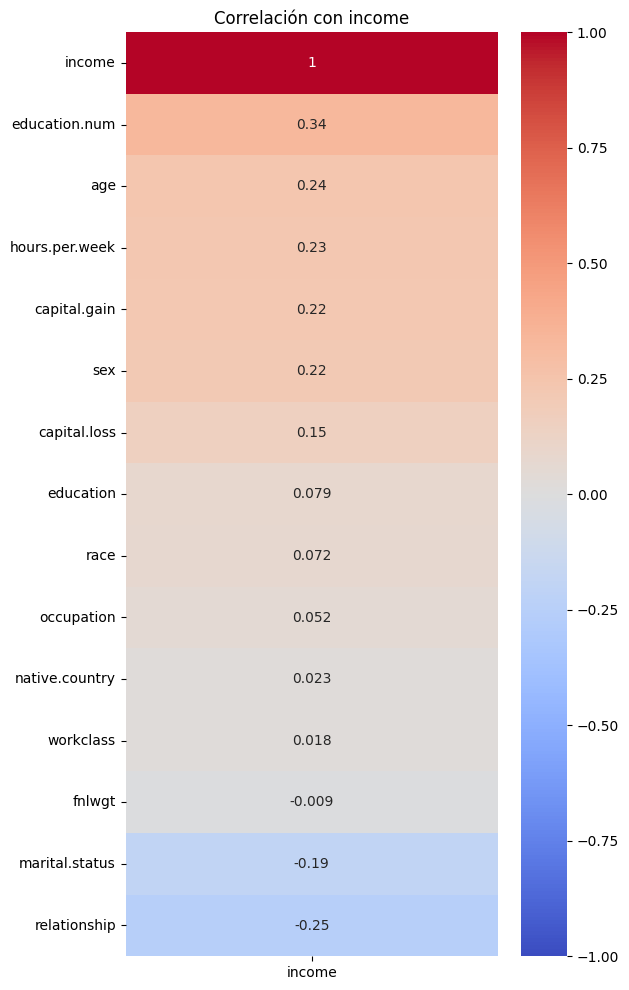

In [ ]:
pd.get_dummies(df)
correlation_matrix = df_corr.corr()
correlation_matrix = correlation_matrix[['income']]  # Reordenamos el heatmap para que 'income' esté en primer lugar
correlation_matrix = correlation_matrix.sort_values(by='income', ascending=False)
plt.figure(figsize=(6, 12)) # Heatmap vertical
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlación con income")
plt.show()

### Eliminamos columnas con baja correlación 

In [ ]:
columnas_a_eliminar = ['fnlwgt', 'relationship', 'marital.status', 'workclass', 'race', 'occupation', 'education', 'native.country']
df = df.drop(columns=columnas_a_eliminar)
df.head(5)

,age,education.num,sex,capital.gain,capital.loss,hours.per.week,income
1,82,9,0,0,4356,18,0
3,54,4,0,0,3900,40,0
4,41,10,0,0,3900,40,0
5,34,9,0,0,3770,45,0
6,38,6,1,0,3770,40,0
